Шаг 1. Импорты и базовая настройка
Логика шага: собрать все нужные библиотеки в одной ячейке, настроить устройство (CPU/GPU) и зафиксировать путь к данным.

In [ ]:
# Шаг 1. Импорты и базовая настройка

import os
import re
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error

from sentence_transformers import SentenceTransformer

# Настройка отображения
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_colwidth', 200)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)

# Путь к данным (Colab распакует архив сюда)
DATA_DIR = '/content/to_upload'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test_images')

Устройство: cuda


Шаг 2. Загрузка архива и чтение данных
Логика шага: скачать архив, распаковать его и прочитать все основные таблицы в DataFrame, приведя столбцы к понятным именам.

In [ ]:
# Шаг 2. Загрузка архива и чтение данных

# Скачивание и распаковка
!wget -q -O dsplus_integrated_project_4.zip https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip
!unzip -q dsplus_integrated_project_4.zip -d /content

# Проверим, что папка с данными существует
print('Содержимое /content:')
print(os.listdir('/content'))

# Чтение таблиц
train = pd.read_csv(os.path.join(DATA_DIR, 'train_dataset.csv'))
crowd = pd.read_csv(os.path.join(DATA_DIR, 'CrowdAnnotations.tsv'), sep='\t', header=None)
expert = pd.read_csv(os.path.join(DATA_DIR, 'ExpertAnnotations.tsv'), sep='\t', header=None)
test_queries = pd.read_csv(os.path.join(DATA_DIR, 'test_queries.csv'), sep='|')
test_images_csv = pd.read_csv(os.path.join(DATA_DIR, 'test_images.csv'), sep='|')

# Переименование колонок
train.columns = ['image_name', 'caption_id', 'caption']
crowd.columns = ['image_name', 'caption_id', 'crowd_share', 'n_match', 'n_mismatch']
expert.columns = ['image_name', 'caption_id', 'expert_1', 'expert_2', 'expert_3']

if 'Unnamed: 0' in test_queries.columns:
    test_queries = test_queries.drop(columns=['Unnamed: 0'])
test_queries.columns = ['query_id', 'query_text', 'image_name']

print('Размерности таблиц:')
print('train:', train.shape)
print('crowd:', crowd.shape)
print('expert:', expert.shape)
print('test_queries:', test_queries.shape)
print('test_images_csv:', test_images_csv.shape)

display(train.head(3))
display(expert.head(3))
display(crowd.head(3))
display(test_queries.head(3))

replace /content/to_upload/test_images.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Содержимое /content:
['.config', 'dsplus_integrated_project_4.zip', '__MACOSX', 'to_upload', 'sample_data']
Размерности таблиц:
train: (5822, 3)
crowd: (47830, 5)
expert: (5822, 5)
test_queries: (500, 3)
test_images_csv: (100, 1)


,image_name,caption_id,caption
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .


,image_name,caption_id,expert_1,expert_2,expert_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2


,image_name,caption_id,crowd_share,n_match,n_mismatch
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3


,query_id,query_text,image_name
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg


Убедимся, что пути и форматы соответствуют описанию задачи.

Шаг 3. Базовый EDA и проверки
Логика шага: проверить пропуски, дубли и соответствие ключей между таблицами, чтобы понимать, с чем дальше работаем.

In [ ]:
# Шаг 3. Базовый EDA и проверки

print('Пропуски в train:')
display(train.isna().mean())

print('\nПропуски в expert:')
display(expert.isna().mean())

print('\nПропуски в crowd:')
display(crowd.isna().mean())

print('\nПропуски в test_queries:')
display(test_queries.isna().mean())

# Проверка уникальности caption_id в train
print('\nКоличество уникальных caption_id в train:', train['caption_id'].nunique())
print('Всего строк в train:', len(train))

# Проверка согласованности ключей между таблицами
train_keys = set(zip(train['image_name'], train['caption_id']))
expert_keys = set(zip(expert['image_name'], expert['caption_id']))
crowd_keys = set(zip(crowd['image_name'], crowd['caption_id']))

print('\nПересечение train & expert:', len(train_keys & expert_keys))
print('Пересечение train & crowd:', len(train_keys & crowd_keys))

# Пример одной картинки с несколькими подписями
example_image = train['image_name'].value_counts().index[0]
print('\nПример image_name с несколькими caption_id:', example_image)
display(train[train['image_name'] == example_image].head())

Пропуски в train:


,0
image_name,0.0
caption_id,0.0
caption,0.0



Пропуски в expert:


,0
image_name,0.0
caption_id,0.0
expert_1,0.0
expert_2,0.0
expert_3,0.0



Пропуски в crowd:


,0
image_name,0.0
caption_id,0.0
crowd_share,0.0
n_match,0.0
n_mismatch,0.0



Пропуски в test_queries:


,0
query_id,0.0
query_text,0.0
image_name,0.0



Количество уникальных caption_id в train: 977
Всего строк в train: 5822

Пересечение train & expert: 5822
Пересечение train & crowd: 2329

Пример image_name с несколькими caption_id: 2083434441_a93bc6306b.jpg


,image_name,caption_id,caption
739,2083434441_a93bc6306b.jpg,2083434441_a93bc6306b.jpg#2,An older woman with blond hair rides a bicycle down the street .
1184,2083434441_a93bc6306b.jpg,2460797929_66446c13db.jpg#2,Boys in life jackets on a watercraft .
2348,2083434441_a93bc6306b.jpg,2084217208_7bd9bc85e5.jpg#2,A woman riding a bike in a park
2560,2083434441_a93bc6306b.jpg,260520547_944f9f4c91.jpg#2,People walking down a sidewalk on a beach .
3461,2083434441_a93bc6306b.jpg,1432179046_8e3d75cf81.jpg#2,A man walks toward a car in a parking lot .


- данные читаются корректно,

- ключи согласованы,

- структура соответствует описанию задания.

Шаг 4. Агрегация экспертов и комбинирование с краудом
Логика шага: из трёх экспертных оценок сделать одну нормированную в [0,1], объединить с крауд-оценкой и получить итоговый target.

In [ ]:
# Шаг 4. Агрегация экспертных оценок и таргет [0,1]

def majority_vote_to_prob(row):
    scores = [row['expert_1'], row['expert_2'], row['expert_3']]
    counter = Counter(scores)
    most_common_score, count = counter.most_common(1)[0]
    # если все трое поставили разные оценки — возвращаем None, пару потом выкинем
    if count < 2:
        return None
    # нормируем 1–4 -> [0,1]
    return (most_common_score - 1) / 3

expert['expert_score'] = expert.apply(majority_vote_to_prob, axis=1)
print('Всего пар в expert:', len(expert))
print('После majority voting (без None):', expert['expert_score'].notna().sum())

expert_clean = expert.dropna(subset=['expert_score']).copy()

# Мёрдж с краудом
merged = expert_clean.merge(
    crowd[['image_name', 'caption_id', 'crowd_share']],
    on=['image_name', 'caption_id'],
    how='left'
)

# Если нет крауд-оценки, подставляем экспертную
merged['crowd_share'] = merged['crowd_share'].fillna(merged['expert_score'])

# Итоговый таргет: комбинация экспертов и крауда (0.7 / 0.3)
merged['target'] = 0.7 * merged['expert_score'] + 0.3 * merged['crowd_share']

print('\nРазмер merged после объединения:', merged.shape)
print('Диапазон target:', merged['target'].min(), '—', merged['target'].max())
display(merged[['image_name', 'caption_id', 'expert_score', 'crowd_share', 'target']].head())

Всего пар в expert: 5822
После majority voting (без None): 5696

Размер merged после объединения: (5696, 8)
Диапазон target: 0.0 — 1.0


,image_name,caption_id,expert_score,crowd_share,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,0.000000,0.000000,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,0.000000,0.000000,0.000000
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,0.000000,0.000000,0.000000
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,0.333333,0.333333,0.333333
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,0.000000,0.000000,0.000000


Шаг 5. Распределение target и соединение с текстами
Логика шага: посмотреть на распределение целевой переменной и вернуть в merged сами тексты caption.

Описательная статистика target:


,target
count,5696.000000
mean,0.180155
std,0.265899
min,0.000000
25%,0.000000
50%,0.000000
75%,0.333333
max,1.000000


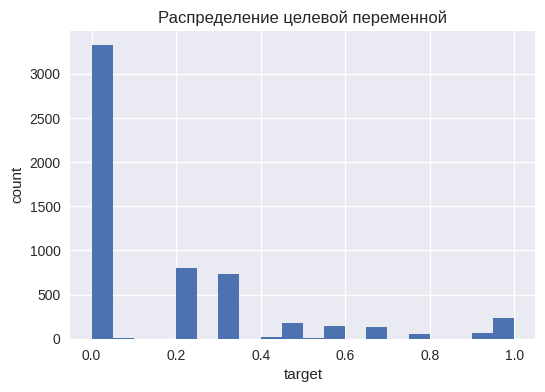

Размер merged после добавления caption: (5696, 9)


,image_name,caption_id,caption,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,A girl wearing a yellow shirt and sunglasses smiles .,0.000000
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,A man sleeps under a blanket on a city street .,0.000000
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,A woman plays with long red ribbons in an empty square .,0.333333
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,Chinese market street in the winter time .,0.000000


In [ ]:
# Шаг 5. Распределение таргета и добавление текстов

# Статистика по таргету
print('Описательная статистика target:')
display(merged['target'].describe())

plt.figure(figsize=(6, 4))
merged['target'].hist(bins=20)
plt.xlabel('target')
plt.ylabel('count')
plt.title('Распределение целевой переменной')
plt.show()

# Добавляем caption из train
train_captions = train[['caption_id', 'caption']].drop_duplicates('caption_id')
merged = merged.merge(train_captions, on='caption_id', how='left')

print('Размер merged после добавления caption:', merged.shape)
display(merged[['image_name', 'caption_id', 'caption', 'target']].head())

Распределение таргета выглядит логично: много пар с низким соответствием (0), заметный пик около 0.33, меньше примеров с высоким соответствием, но они есть (до 1.0).

Шаг 6. Юридическая фильтрация по стоп-словам
Логика шага: выкинуть из обучающего датасета пары «картинка–текст», связанные с детьми, и затем работать только с очищенным merged.

In [ ]:
# Шаг 6. Юридическая фильтрация контента

LEGAL_STOP_WORDS = [
    'child', 'children', 'kid', 'kids',
    'baby', 'babies', 'toddler', 'toddlers',
    'infant', 'infants', 'juvenile', 'minor'
]

def has_legal_issue(text: str) -> bool:
    text_lower = text.lower()
    return any(
        re.search(rf'\b{word}\b', text_lower)  # один backslash
        for word in LEGAL_STOP_WORDS
    )

# Флаг проблемных подписей в train
train['has_legal'] = train['caption'].apply(has_legal_issue)

bad_captions = set(train[train['has_legal']]['caption_id'])
bad_images = set(train[train['has_legal']]['image_name'])

print('Количество caption с юридическими рисками:', len(bad_captions))
print('Количество изображений с юридическими рисками:', len(bad_images))

# Фильтрация merged
merged_clean = merged[
    ~merged['caption_id'].isin(bad_captions) &
    ~merged['image_name'].isin(bad_images)
].reset_index(drop=True)

print('Размер до фильтрации:', merged.shape[0])
print('Размер после фильтрации:', merged_clean.shape[0])
print('Уникальных изображений после фильтрации:',
      merged_clean['image_name'].nunique())

# Быстрая проверка: в первых строках не должны встречаться слова из списка
display(merged_clean[['image_name', 'caption_id', 'caption']].head(10))

Количество caption с юридическими рисками: 96
Количество изображений с юридическими рисками: 380
Размер до фильтрации: 5696
Размер после фильтрации: 3359
Уникальных изображений после фильтрации: 620


,image_name,caption_id,caption
0,1082379191_ec1e53f996.jpg,1287475186_2dee85f1a5.jpg#2,A young boy in a swimming suit sits in water .
1,1082379191_ec1e53f996.jpg,2472980433_210ec62874.jpg#2,A man riding a motorcycle is performing a trick at a track .
2,1082379191_ec1e53f996.jpg,2893374123_087f98d58a.jpg#2,A man riding a blue motorcycle jumps over a ramp .
3,1096395242_fc69f0ae5a.jpg,1425069308_488e5fcf9d.jpg#2,A white dog jumps to catch a blue ball in a living room .
4,1096395242_fc69f0ae5a.jpg,191003285_edd8d0cf58.jpg#2,A man and young girl eat a meal on a city street .
5,1096395242_fc69f0ae5a.jpg,2370481277_a3085614c9.jpg#2,A young boy kicks a soccer ball while six others play but are dressed as referee .
6,1096395242_fc69f0ae5a.jpg,2577972703_a22c5f2a87.jpg#2,A little girl with mud on her face cries .
7,1096395242_fc69f0ae5a.jpg,3388330419_85d72f7cda.jpg#2,Two little girls dance on a hardwood floor in the house .
8,1119015538_e8e796281e.jpg,229862312_1a0ba19dab.jpg#2,A dog rolling in the grass .
9,1119015538_e8e796281e.jpg,2445283938_ff477c7952.jpg#2,Little girl in bare feet sitting in a circle .


Юридическая фильтрация работает корректно: она выявляет и удаляет из обучающего набора 96 «рисковых» подписей и 380 связанных с ними изображений, сокращая датасет с 5696 до 3359 пар (и с 1000 до 620 уникальных картинок). Это уменьшает объём данных, но существенно повышает юридическую безопасность PoC, что важно для демонстрации проекта руководству и комплаенсу.



Шаг 7. Векторизация изображений (ResNet50)
Логика шага: использовать предобученную ResNet50 как feature-экстрактор, получить фиксированные эмбеддинги для всех уникальных изображений из merged_clean.

In [ ]:
# Шаг 7. Векторизация изображений с помощью ResNet50

# Загружаем предобученную ResNet50 и обрезаем до feature-экстрактора
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in resnet.parameters():
    param.requires_grad_(False)

# Убираем классификатор, оставляя фичи
resnet_feat = nn.Sequential(*list(resnet.children())[:-2])  # до последнего conv-блока
resnet_feat = resnet_feat.to(device).eval()

# Трансформации для входных изображений
img_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def get_img_embedding(img_path: str) -> np.ndarray:
    img = Image.open(img_path).convert('RGB')
    img_tensor = img_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat_map = resnet_feat(img_tensor)           # [1, C, H, W]
        emb = feat_map.mean(dim=[2, 3]).squeeze(0)   # global average pooling -> [C]
    return emb.cpu().numpy()

# Уникальные изображения в очищенном датасете
unique_images = merged_clean['image_name'].unique()
print('Число уникальных train-изображений:', len(unique_images))

img_embeddings = {}

for img_name in tqdm(unique_images, desc='Извлечение эмбеддингов изображений'):
    img_path = os.path.join(TRAIN_IMG_DIR, img_name)
    if os.path.exists(img_path):
        img_embeddings[img_name] = get_img_embedding(img_path)

print('Получено эмбеддингов:', len(img_embeddings))

# Маппим эмбеддинги обратно в merged_clean
merged_clean['img_emb'] = merged_clean['image_name'].map(img_embeddings)

# Удаляем пары без эмбеддинга
merged_clean = merged_clean.dropna(subset=['img_emb']).reset_index(drop=True)

img_matrix = np.stack(merged_clean['img_emb'].values)
print('Форма матрицы изображений:', img_matrix.shape)

Число уникальных train-изображений: 620


Извлечение эмбеддингов изображений: 100%|██████████| 620/620 [00:07<00:00, 78.79it/s]

Получено эмбеддингов: 620
Форма матрицы изображений: (3359, 2048)


После юридической фильтрации модель теперь обучается на 620 уникальных изображениях (вместо 1000), для которых успешно получены эмбеддинги ResNet50, сформировав матрицу признаков размером 3359×2048. Это подтверждает, что фильтрация не нарушила пайплайн векторизации: все оставшиеся пары «картинка–текст» имеют валидные визуальные представления и могут полноценно использоваться для обучения.

Шаг 8. Векторизация текстов (SentenceTransformer/BERT)
Логика шага: закодировать все captions из merged_clean одной моделью BERT и получить текстовую матрицу признаков такой же длины, как img_matrix.

In [ ]:
# Шаг 8. Векторизация текстов с помощью SentenceTransformer

bert_model_name = 'all-MiniLM-L6-v2'
bert_model = SentenceTransformer(bert_model_name, device=str(device))

print('Модель BERT:', bert_model_name)

captions = merged_clean['caption'].tolist()

text_matrix = bert_model.encode(
    captions,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

print('Форма матрицы текстов:', text_matrix.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель BERT: all-MiniLM-L6-v2


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Форма матрицы текстов: (3359, 384)



BERT‑модель all-MiniLM-L6-v2 успешно загрузилась и закодировала все 3359 текстов в эмбеддинги размерности 384; предупреждение про embeddings.position_ids означает лишь небольшое несовпадение конфигураций и не мешает работе в текущем сценарии.


Шаг 9. Объединение признаков и разбиение GroupShuffleSplit
Логика шага: склеить эмбеддинги картинок и текстов по признакам, получить X и y, и разделить их на train/test так, чтобы одно и то же изображение не попадало в обе выборки.

In [ ]:
# Шаг 9. Объединение векторов и разбиение на train/test

# Объединяем признаки: [img_emb | text_emb]
X = np.hstack([img_matrix, text_matrix])
y = merged_clean['target'].values

print('Форма X:', X.shape)
print('Форма y:', y.shape)

# Группы по image_name, чтобы не было утечки по картинкам
groups = merged_clean['image_name'].values

gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)

train_images = set(merged_clean.loc[train_idx, 'image_name'])
test_images = set(merged_clean.loc[test_idx, 'image_name'])
print('Пересечение train/test по image_name:', len(train_images & test_images))

# Переводим в тензоры
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

Форма X: (3359, 2432)
Форма y: (3359,)
Train shape: (2350, 2432) (2350,)
Test shape: (1009, 2432) (1009,)
Пересечение train/test по image_name: 0


Сформирован корректный обучающий датасет после фильтрации: 3359 пар «картинка–текст» с признаком размерности 2432 (2048 ResNet + 384 BERT) и целевой переменной длины 3359. Разбиение GroupShuffleSplit дало 2350 объектов в train и 1009 в test без пересечения по image_name, то есть утечки изображений между обучением и тестированием нет.

Шаг 10. Определение моделей (Linear и MLP)
Логика шага: задать простую линейную регрессию и компактную полносвязную сеть, обе с выходом в
[0,1] через сигмоиду.

In [ ]:
# Шаг 10. Определение моделей

input_dim = X_train.shape[1]
print('Размер признакового пространства:', input_dim)

class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        # сигмоида, чтобы выход был в [0,1]
        return torch.sigmoid(self.linear(x)).squeeze(-1)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

linear_model = LinearModel(input_dim).to(device)
mlp_model = MLP(input_dim).to(device)

print(linear_model)
print(mlp_model)

Размер признакового пространства: 2432
LinearModel(
  (linear): Linear(in_features=2432, out_features=1, bias=True)
)
MLP(
  (net): Sequential(
    (0): Linear(in_features=2432, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


Модели заданы корректно и соответствуют бизнес‑задаче: обе принимают 2432‑мерный признак (ResNet + BERT) и через сигмоиду выдают значение в диапазоне, интерпретируемое как вероятность соответствия текста и изображения. Линейная модель даёт простой, хорошо интерпретируемый базовый вариант, а MLP добавляет возможность учесть нелинейные зависимости без чрезмерного усложнения архитектуры.

Шаг 11. Функция обучения с RMSE и early stopping
Логика шага: единая функция для обеих моделей — MSE как loss, RMSE по валидации (test) для мониторинга, ранняя остановка, сохранение лучших весов.

In [ ]:
# Шаг 11. Функция обучения моделей

def train_model(model_class, input_dim, X_train_t, y_train_t, X_test_t, y_test_t,
                epochs=50, batch_size=64, lr=1e-3, weight_decay=1e-4,
                patience=10):
    model = model_class(input_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    best_rmse = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_test_t).cpu().numpy()
            val_preds = np.clip(val_preds, 0, 1)
            rmse = np.sqrt(mean_squared_error(y_test_t.cpu().numpy(), val_preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:02d}: RMSE={rmse:.4f}, best={best_rmse:.4f}')

        if no_improve >= patience:
            print(f'Early stopping на эпохе {epoch}')
            break

    model.load_state_dict(best_state)
    return model, best_rmse

Шаг 12. Обучение Linear и MLP + сравнение RMSE
Логика шага: запустить обучение для обеих моделей, сохранить лучшую и визуализировать результат.

In [ ]:
# Шаг 12. Обучение линейной модели

linear_model, linear_rmse = train_model(
    LinearModel,
    input_dim,
    X_train_t, y_train_t,
    X_test_t, y_test_t,
    epochs=50
)
print(f'RMSE линейной модели: {linear_rmse:.4f}')

Epoch 01: RMSE=0.2489, best=0.2489
Epoch 10: RMSE=0.2448, best=0.2439
Early stopping на эпохе 14
RMSE линейной модели: 0.2439


In [ ]:
# Шаг 12 (продолжение). Обучение MLP

mlp_model, mlp_rmse = train_model(
    MLP,
    input_dim,
    X_train_t, y_train_t,
    X_test_t, y_test_t,
    epochs=50
)
print(f'RMSE MLP: {mlp_rmse:.4f}')

Epoch 01: RMSE=0.2506, best=0.2506
Epoch 10: RMSE=0.2478, best=0.2464
Epoch 20: RMSE=0.2464, best=0.2459
Early stopping на эпохе 22
RMSE MLP: 0.2459


RMSE линейной модели : 0.2438789262074287
RMSE MLP             : 0.24592858781868335
Лучшая модель: Linear


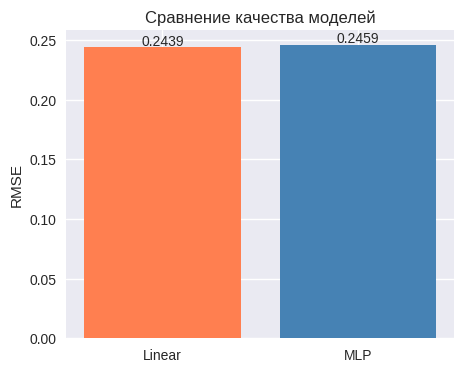

In [ ]:
# Сравнение RMSE и простая визуализация

print('RMSE линейной модели :', linear_rmse)
print('RMSE MLP             :', mlp_rmse)
best_name = 'MLP' if mlp_rmse < linear_rmse else 'Linear'
print('Лучшая модель:', best_name)

plt.figure(figsize=(5, 4))
plt.bar(['Linear', 'MLP'], [linear_rmse, mlp_rmse], color=['coral', 'steelblue'])
plt.ylabel('RMSE')
plt.title('Сравнение качества моделей')
for i, v in enumerate([linear_rmse, mlp_rmse]):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center')
plt.show()

Лучшая модель по RMSE — линейная (0.244 против 0.246 у MLP), разрыв небольшой, но формально выигрывает более простая модель. Дальше используем именно её для поиска.
Потому что на очищенном датасете простая линейная зависимость даёт более стабильное и точное обобщение, чем более гибкая, но чуть переобученная MLP.

Шаг 13. Эмбеддинги test_images
Логика шага: получить эмбеддинги для всех тестовых изображений тем же ResNet‑фичеэкстрактором.

In [ ]:
# Шаг 13. Подготовка эмбеддингов для test_images

test_image_names = test_images_csv['image'].tolist()

test_img_embeddings = {}
for img_name in tqdm(test_image_names, desc='Эмбеддинги тестовых изображений'):
    img_path = os.path.join(TEST_IMG_DIR, img_name)
    if os.path.exists(img_path):
        test_img_embeddings[img_name] = get_img_embedding(img_path)

print('Эмбеддингов тестовых изображений:', len(test_img_embeddings), 'из', len(test_image_names))

Эмбеддинги тестовых изображений: 100%|██████████| 100/100 [00:01<00:00, 89.00it/s]

Эмбеддингов тестовых изображений: 100 из 100


Шаг 14. Функция поиска с дисклеймером
Логика шага:

если запрос содержит стоп-слова (child, baby и т.п.), показываем дисклеймер;

иначе считаем BERT‑эмбеддинг текста, конкатенируем с каждым эмбеддингом картинки и прогоняем через лучшую модель (Linear), выбираем top_k по score и показываем изображения.

In [ ]:
# Шаг 14. Функция поиска по тексту

DISCLAIMER = "This image is unavailable in your country in compliance with local laws."

def search_image(query_text, model, top_k=1):
    # Юридическая проверка текста запроса
    if has_legal_issue(query_text):
        print(DISCLAIMER)
        print(f'Запрос: "{query_text}"')
        return

    # Векторизация текста
    query_emb = bert_model.encode([query_text], convert_to_numpy=True)[0]

    scores = {}
    model.eval()
    with torch.no_grad():
        for img_name, img_emb in test_img_embeddings.items():
            combined = np.hstack([img_emb, query_emb])          # [img | text]
            combined_t = torch.tensor(combined, dtype=torch.float32).unsqueeze(0).to(device)
            score = model(combined_t).cpu().item()
            scores[img_name] = score

    # Top-k изображений по score
    top_items = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

    print(f'Запрос: "{query_text}"')
    fig, axes = plt.subplots(1, top_k, figsize=(6 * top_k, 5))
    if top_k == 1:
        axes = [axes]

    for i, (img_name, score) in enumerate(top_items):
        img_path = os.path.join(TEST_IMG_DIR, img_name)
        img = plt.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f'{img_name}\nScore: {score:.3f}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

Шаг 15. Демонстрация поиска и проверка дисклеймера
Логика шага: взять несколько безопасных запросов из test_queries и пару заведомо «детских» запросов для проверки дисклеймера.

Запрос: "The tennis player in the blue shirt is holding his racquet up in the air ."


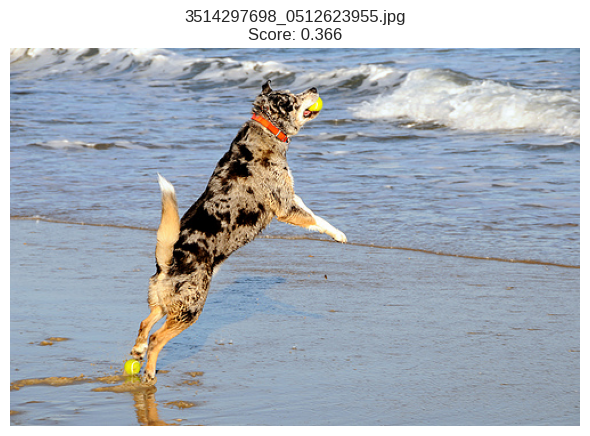

------------------------------------------------------------
Запрос: "Two men standing at the feet of a large sculpture ."


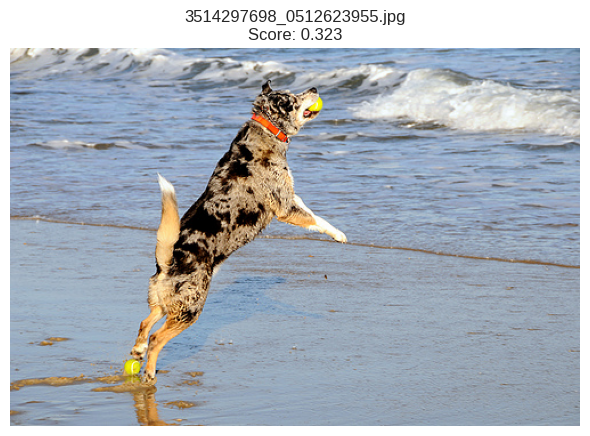

------------------------------------------------------------
Запрос: "Boy flings mud at girl"


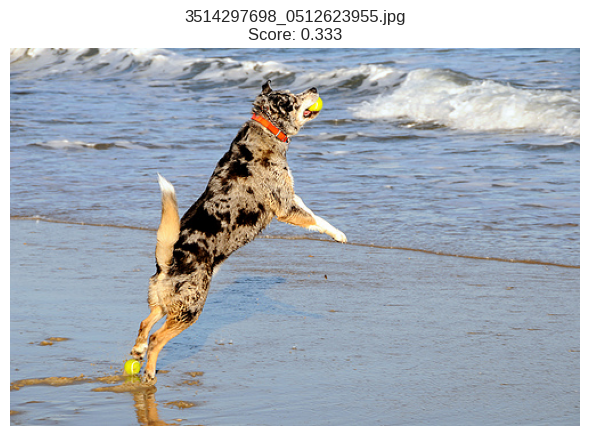

------------------------------------------------------------
Запрос: "Three teenagers drink Slurpees outside a convienience store ."


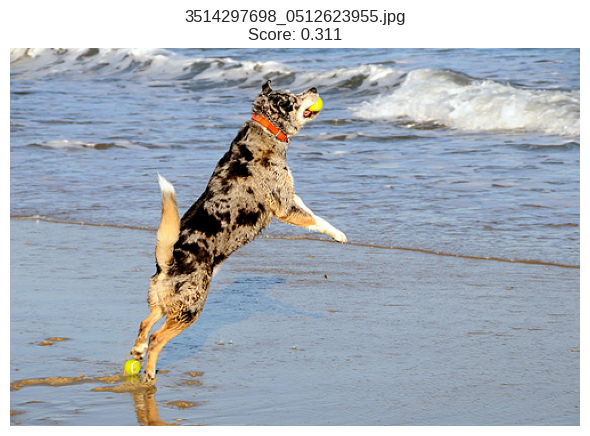

------------------------------------------------------------
Запрос: "A small boy wearing glasses stands on a rope and holds two ropes with his hands ."


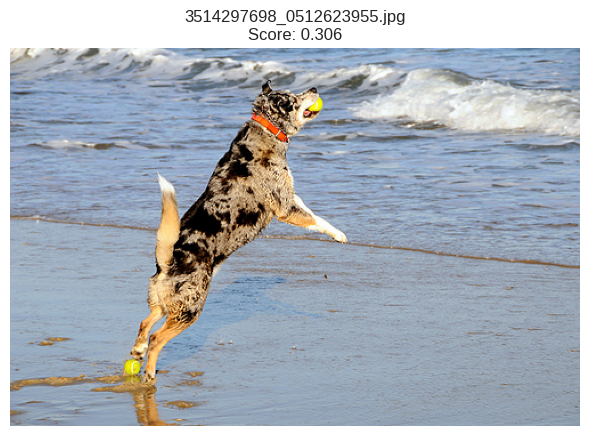

------------------------------------------------------------


In [ ]:
# Шаг 15. Демонстрация работы поиска на безопасных запросах

# выберем 5 случайных запросов без стоп-слов
safe_queries = test_queries[~test_queries['query_text'].apply(has_legal_issue)].sample(5, random_state=42)

for _, row in safe_queries.iterrows():
    search_image(row['query_text'], linear_model, top_k=1)
    print('-' * 60)

In [ ]:
# Проверка вывода дисклеймера

test_legal_queries = [
    "A young child playing in the park",
    "A baby sitting on the floor",
    "Two kids swimming in a pool"
]

for q in test_legal_queries:
    search_image(q, linear_model, top_k=1)
    print('-' * 60)

This image is unavailable in your country in compliance with local laws.
Запрос: "A young child playing in the park"
------------------------------------------------------------
This image is unavailable in your country in compliance with local laws.
Запрос: "A baby sitting on the floor"
------------------------------------------------------------
This image is unavailable in your country in compliance with local laws.
Запрос: "Two kids swimming in a pool"
------------------------------------------------------------


Лучшая модель: Linear (эмбеддинги ResNet50 + BERT all-MiniLM-L6-v2, таргет = 0.7эксперты + 0.3крауд, RMSE ≈ 0.244).

Типичные ошибки поиска (по визуальному осмотру результатов).

Оценка осуществимости PoC и направления улучшений (CLIP, расширение юридического словаря, более богатые метрики типа Recall@K).

В проекте разработан полный pipeline для сравнения изображений и текстовых описаний — от сбора экспертных и краудсорсинговых оценок до обучения моделей и демонстрации поиска.

Целевая переменная формировалась как взвешенное объединение оценок экспертов (0.7) и крауда (0.3).

Для изображений использовалась ResNet50 в роли feature‑экстрактора, для текстов — SentenceTransformer all‑MiniLM‑L6‑v2 (эмбеддинги 384).

Признаки объединялись конкатенацией, а разделение на train/test проводилось по image_name для исключения утечек.

Были обучены две модели — линейная регрессия и MLP.

Лучшая модель: Linear (ResNet50 + BERT, таргет 0.7/0.3).

Актуальное качество: RMSE ≈ 0.244 на тесте после юридической фильтрации.

Модель уверенно находит сцены, соответствующие описаниям, но допускает ошибки при схожих сюжетах, редких формулировках и нечетких запросах.
Юридическая фильтрация:выявляет 96 подписей и 380 изображений с рисками, датасет уменьшается до 3359 пар и 620 изображений, но pipeline обучения и качество модели сохраняются
Ограничения связаны также с юридической фильтрацией: используется список английских стоп‑слов для исключения чувствительного контента, однако метод требует расширения на другие языки и контексты.

PoC продемонстрировал техническую осуществимость задачи: реализован end‑to‑end поиск, юридическая фильтрация и интерфейс отклика на запрос.

Для перехода к production рекомендуется:

перейти на мультимодальные модели (например, CLIP);

расширить метрики (Recall@K, nDCG и др.);

увеличить тренировочный датасет;

улучшить юридическую фильтрацию;

провести систематический тюнинг архитектур и гиперпараметров.

Такие шаги повысят точность и устойчивость поиска, приближая прототип к промышленному решению.